## Radiative Heating and Precipitation Relation

### Import package

In [69]:
import numpy as np
import netCDF4 as nc

from pathlib import Path
from datetime import datetime

from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm

### Helper functions

In [70]:
def convert_time(time_variable: nc.Variable) -> np.ndarray:
    """Return a netCDF time coordinate as YYYY-MM-DD strings."""
    dates = nc.num2date(
        time_variable[:],
        units=time_variable.units,
        calendar=getattr(time_variable, "calendar", "standard"),
    )
    return np.asarray([date.strftime("%Y-%m-%d") for date in dates])


def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a netCDF array to float and replace masked values by NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float64)
    return np.asarray(masked_values.filled(np.nan))


def symmetrize_about_equator(data: np.ndarray) -> np.ndarray:
    """Return the equatorially symmetric component of time-lat-lon data."""
    if data.ndim != 3:
        raise ValueError("Expected data with dimensions (time, latitude, longitude).")
    return 0.5 * (data + np.flip(data, axis=1))


def make_windowed_chunks(
    data: np.ndarray,
    chunk_size: int,
    overlap: int,
    window: np.ndarray,
) -> np.ndarray:
    """Split time-lat-lon data into overlapping, windowed segments."""
    if data.ndim != 3:
        raise ValueError("Expected data with dimensions (time, latitude, longitude).")
    if not 0 <= overlap < chunk_size:
        raise ValueError("overlap must satisfy 0 <= overlap < chunk_size.")
    if window.shape != (chunk_size,):
        raise ValueError("window length must equal chunk_size.")
    if data.shape[0] < chunk_size:
        raise ValueError("The time dimension is shorter than one chunk.")

    step = chunk_size - overlap
    starts = range(0, data.shape[0] - chunk_size + 1, step)
    return np.stack(
        [
            data[start : start + chunk_size] * window[:, None, None]
            for start in starts
        ]
    )


def space_time_transform(
    data: np.ndarray,
    time_axis: int,
    longitude_axis: int,
) -> np.ndarray:
    """Transform data into frequency-zonal-wavenumber space.

    The inverse time FFT and forward longitude FFT preserve the notebook's
    propagation convention. The result is normalized by both dimensions.
    """
    transformed = np.fft.ifft(data, axis=time_axis)
    transformed = np.fft.fft(transformed, axis=longitude_axis)
    return transformed / data.shape[longitude_axis]


def calc_cross_spectrum(
    data1: np.ndarray,
    data2: np.ndarray,
    time_axis: int = 0,
    longitude_axis: int = 1,
) -> np.ndarray:
    """Return S12 = F(data1) * conj(F(data2))."""
    if data1.shape != data2.shape:
        raise ValueError("Input arrays must have identical shapes.")

    spectrum1 = space_time_transform(data1, time_axis, longitude_axis)
    spectrum2 = space_time_transform(data2, time_axis, longitude_axis)
    return spectrum1 * np.conj(spectrum2)


def calculate_segment_spectra(
    source_chunks: dict[str, np.ndarray],
    reference_chunks: np.ndarray,
    window: np.ndarray,
) -> tuple[dict[str, np.ndarray], dict[str, np.ndarray], np.ndarray]:
    """Calculate latitude-mean cross- and auto-spectra per segment.

    All chunk arrays must be shaped (segment, time, latitude, longitude).
    Processing one segment at a time avoids large four-dimensional FFT
    temporaries. The returned spectral arrays are shaped
    (segment, frequency, zonal_wavenumber).
    """
    if reference_chunks.ndim != 4:
        raise ValueError(
            "reference_chunks must have dimensions "
            "(segment, time, latitude, longitude)."
        )
    if not source_chunks:
        raise ValueError("At least one source field is required.")
    if any(data.shape != reference_chunks.shape for data in source_chunks.values()):
        raise ValueError("All source and reference chunks must have identical shapes.")

    n_segments, n_times, _, n_longitudes = reference_chunks.shape
    if window.shape != (n_times,):
        raise ValueError("The window length must match the chunk time dimension.")

    window_energy = np.mean(window**2)
    if window_energy <= 0:
        raise ValueError("The window must have positive mean-square energy.")

    output_shape = (n_segments, n_times, n_longitudes)
    cross_by_source = {
        name: np.empty(output_shape, dtype=np.complex128)
        for name in source_chunks
    }
    power_by_source = {
        name: np.empty(output_shape, dtype=np.float64)
        for name in source_chunks
    }
    reference_power = np.empty(output_shape, dtype=np.float64)

    for segment in range(n_segments):
        # A segment is shaped (time, latitude, longitude), so the correct
        # transform axes are time=0 and longitude=2.
        reference_fft = space_time_transform(
            reference_chunks[segment], time_axis=0, longitude_axis=2
        )
        reference_power[segment] = (
            np.nanmean(np.abs(reference_fft) ** 2, axis=1) / window_energy
        )

        for name, source in source_chunks.items():
            source_fft = space_time_transform(
                source[segment], time_axis=0, longitude_axis=2
            )
            cross_by_source[name][segment] = (
                np.nanmean(source_fft * np.conj(reference_fft), axis=1)
                / window_energy
            )
            power_by_source[name][segment] = (
                np.nanmean(np.abs(source_fft) ** 2, axis=1) / window_energy
            )

    return cross_by_source, power_by_source, reference_power


def calculate_squared_coherence(
    mean_cross_spectrum: np.ndarray,
    mean_source_power: np.ndarray,
    mean_reference_power: np.ndarray,
) -> np.ndarray:
    """Return |<Sxy>|^2 / (<Sxx><Syy>) with safe division."""
    denominator = mean_source_power * mean_reference_power
    coherence = np.divide(
        np.abs(mean_cross_spectrum) ** 2,
        denominator,
        out=np.full_like(denominator, np.nan, dtype=np.float64),
        where=denominator > 0,
    )
    return np.clip(coherence, 0.0, 1.0)


### Configuration and data loading

In [71]:
DATA_PATH = Path("/data92/b11209013")
START_DATE = datetime(2006, 1, 1).strftime("%Y-%m-%d")
END_DATE = datetime(2018, 1, 1).strftime("%Y-%m-%d")
LATITUDE_BOUNDS = (-5.0, 5.0)

# Longwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_LW_rm3harm.nc") as dataset:
    radiative_dates = convert_time(dataset.variables["time"])
    radiative_latitude = as_float_array(dataset.variables["lat"][:])
    radiative_longitude = as_float_array(dataset.variables["lon"][:])
    radiative_latitude_mask = (
        (radiative_latitude >= LATITUDE_BOUNDS[0])
        & (radiative_latitude <= LATITUDE_BOUNDS[1])
    )
    lw_heating = as_float_array(
        dataset.variables["column_LW"][:, radiative_latitude_mask, :]
    )

# Shortwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_SW_rm3harm.nc") as dataset:
    shortwave_dates = convert_time(dataset.variables["time"])
    sw_heating = as_float_array(
        dataset.variables["column_SW"][:, radiative_latitude_mask, :]
    )

# Precipitation
with nc.Dataset(DATA_PATH / "IMERG" / "DATA" / "IMERG_1deg.nc") as dataset:
    all_precipitation_dates = convert_time(dataset.variables["time"])
    date_mask = (all_precipitation_dates >= START_DATE) & (
        all_precipitation_dates < END_DATE
    )
    precipitation_dates = all_precipitation_dates[date_mask]

    precipitation_latitude = as_float_array(dataset.variables["lat"][:])
    precipitation_longitude = as_float_array(dataset.variables["lon"][:])
    precipitation_latitude_mask = (
        (precipitation_latitude >= LATITUDE_BOUNDS[0])
        & (precipitation_latitude <= LATITUDE_BOUNDS[1])
    )
    precipitation = as_float_array(
        dataset.variables["precipitation"][
            date_mask, precipitation_latitude_mask, :
        ]
    )


### Preprocessing and segmentation

In [72]:
CHUNK_SIZE = 96
CHUNK_OVERLAP = CHUNK_SIZE // 2
hann_window = np.hanning(CHUNK_SIZE)

qr_heating = lw_heating + sw_heating

# symmetrizing the data
symmetric_fields = {
    "QR": (qr_heating + np.flip(qr_heating, axis=1)) / 2,
    "LW": (lw_heating + np.flip(lw_heating, axis=1)) / 2,
    "SW": (sw_heating + np.flip(sw_heating, axis=1)) / 2,
    "precipitation": (precipitation + np.flip(precipitation, axis=1)) / 2,
}

# chunking data
chunking_fields = {
    key: np.array([
        symmetric_fields[key][start : start + CHUNK_SIZE] * hann_window[:, None, None]
        for start in range(0, symmetric_fields[key].shape[0] - CHUNK_SIZE + 1, CHUNK_SIZE - CHUNK_OVERLAP)
    ])
    for key in symmetric_fields.keys()
}

n_segments, _, n_latitudes, n_longitudes = chunking_fields["QR"].shape
print(f"Windowed chunk shape: {chunking_fields['QR'].shape}")

Windowed chunk shape: (90, 96, 10, 360)


### Cross-spectral analysis

In [73]:
frequencies = np.fft.fftfreq(CHUNK_SIZE, d=1.0)
zonal_wavenumbers = np.fft.fftfreq(
    n_longitudes, d=1.0 / n_longitudes
)

source_chunks = {
    name: chunking_fields[name]
    for name in ("QR", "LW", "SW")
}

# Calculate one latitude-mean estimate for every time segment.
cross_spectrum, power_spectrum, precipitation_power_spectrum = (
    calculate_segment_spectra(
        source_chunks=source_chunks,
        reference_chunks=chunking_fields["precipitation"],
        window=hann_window,
    )
)

# Average across segments only; latitude was averaged in the function.
mean_cross_spectrum = {
    name: np.nanmean(values, axis=0)
    for name, values in cross_spectrum.items()
}
mean_power_spectrum = {
    name: np.nanmean(values, axis=0)
    for name, values in power_spectrum.items()
}
mean_precipitation_power_spectrum = np.nanmean(
    precipitation_power_spectrum, axis=0
)

# Form coherence from averaged spectra. Per-periodogram coherence is one.
coherence_squared = {
    name: calculate_squared_coherence(
        mean_cross_spectrum=mean_cross_spectrum[name],
        mean_source_power=mean_power_spectrum[name],
        mean_reference_power=mean_precipitation_power_spectrum,
    )
    for name in source_chunks
}

cospectrum = {
    name: values.real for name, values in mean_cross_spectrum.items()
}
quadrature_spectrum = {
    name: values.imag for name, values in mean_cross_spectrum.items()
}
phase_degrees = {
    name: np.rad2deg(np.angle(values))
    for name, values in mean_cross_spectrum.items()
}


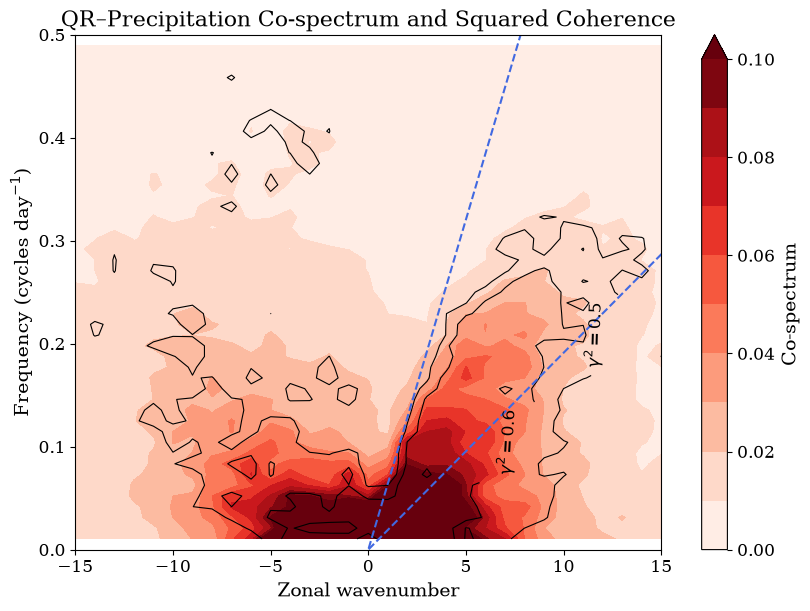

In [ ]:
SOURCE_NAME = "LW"
COHERENCE_LEVELS = (0.5, 0.6, 0.8)

shifted_wavenumbers = np.fft.fftshift(zonal_wavenumbers)
shifted_frequencies = np.fft.fftshift(frequencies)
shifted_cospectrum = np.fft.fftshift(
    cospectrum[SOURCE_NAME], axes=(0, 1)
)
shifted_coherence = np.fft.fftshift(
    coherence_squared[SOURCE_NAME], axes=(0, 1)
)

# Retain positive temporal frequencies for the conventional display.
positive_frequency = shifted_frequencies > 0
frequency_display = shifted_frequencies[positive_frequency]
cospectrum_display = shifted_cospectrum[positive_frequency, :]
coherence_display = shifted_coherence[positive_frequency, :]

# Use a robust symmetric range so both covariance signs remain visible.
finite_cospectrum = np.abs(
    cospectrum_display[np.isfinite(cospectrum_display)]
)
if finite_cospectrum.size == 0:
    raise ValueError("The co-spectrum contains no finite values.")
color_limit = np.percentile(finite_cospectrum, 99)
color_limit = color_limit if color_limit > 0 else 1.0
shading_levels = np.linspace(0, 0.1, 11)


plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)

figure, axis = plt.subplots(figsize=(8, 6), constrained_layout=True)

shading = axis.contourf(
    shifted_wavenumbers,
    frequency_display,
    cospectrum_display,
    levels=shading_levels,
    cmap="Reds",
    extend="max",
)

finite_coherence = coherence_display[np.isfinite(coherence_display)]
available_coherence_levels = []
if finite_coherence.size:
    available_coherence_levels = [
        level
        for level in COHERENCE_LEVELS
        if finite_coherence.min() < level < finite_coherence.max()
    ]
if available_coherence_levels:
    coherence_contours = axis.contour(
        shifted_wavenumbers,
        frequency_display,
        coherence_display,
        levels=available_coherence_levels,
        colors="black",
        linewidths=0.8,
    )
    axis.clabel(
        coherence_contours,
        fmt=lambda value: rf"$\gamma^2={value:.1f}$",
        fontsize=12,
        inline=True,
    )

axis.plot(
    shifted_wavenumbers,
    np.sqrt(9.81 * 8) * 86400.0 / (2*np.pi*6.371e6) * shifted_wavenumbers,
    color="royalblue", linestyle="--"
)

axis.plot(
    shifted_wavenumbers,
    np.sqrt(9.81 * 90) * 86400.0 / (2*np.pi*6.371e6) * shifted_wavenumbers,
    color="royalblue", linestyle="--"
)

axis.set(
    xlim=(-15, 15),
    ylim=(0, 0.5),
    xlabel="Zonal wavenumber",
    ylabel="Frequency (cycles day$^{-1}$)",
    title=f"{SOURCE_NAME}–Precipitation Co-spectrum and Squared Coherence",
)
cbar = figure.colorbar(shading, ax=axis, label="Co-spectrum")
cbar.set_ticks([0, 0.02, 0.04, 0.06, 0.08, 0.1])
plt.savefig(f"/home/b11209013/Manuscript_Prep/KW_CRI/Figure/Qr_Prec/{SOURCE_NAME}.png", dpi=600, bbox_inches="tight")